EXPLORATORY DATA ANALYSIS - EGYPT REAL ESTATE
Working directory: F:\Egypt-Real-Estate-Appraiser

📊 Loading cleaned data...
✅ Dataset shape: (16083, 7)
Columns: ['location', 'type', 'size_sqm', 'bedrooms_num', 'bathrooms', 'payment_method', 'price']

Missing values after loading:
size_sqm        0
bedrooms_num    0
bathrooms       0
price           0
dtype: int64

📈 Creating price distribution plots...


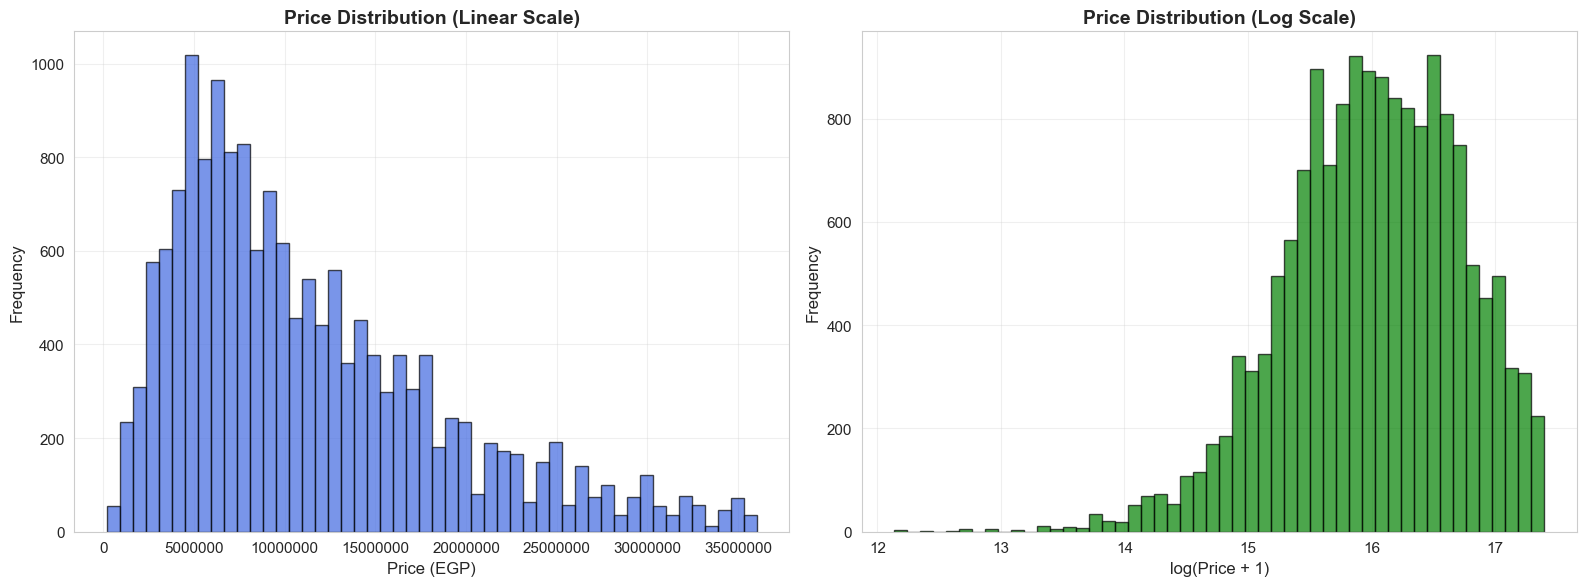

✅ Price statistics:
  Mean: 11,272,991 EGP
  Median: 9,300,000 EGP
  Std Dev: 7,426,339 EGP
  Range: 186,900 - 36,035,000 EGP

📊 Creating boxplot by property type...


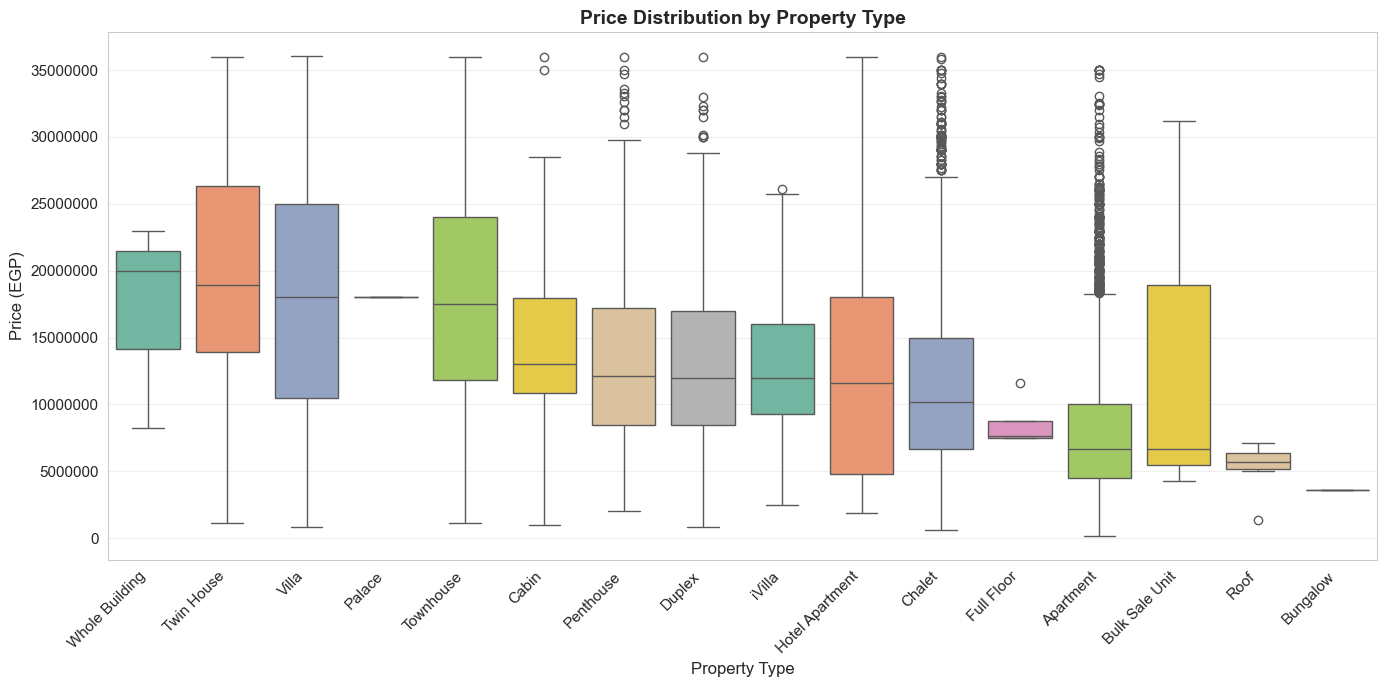

✅ Average Price by Property Type:
                 count        mean      median
type                                          
Twin House         525  19762404.0  18900000.0
Villa             1596  18096423.0  18000000.0
Palace               1  18000000.0  18000000.0
Townhouse         1127  17893490.0  17500000.0
Whole Building       3  17081373.0  20000000.0
Cabin               37  14677658.0  13000000.0
Bulk Sale Unit       3  14034667.0   6668000.0
Penthouse          518  13412780.0  12151546.0
Hotel Apartment     92  13198516.0  11618000.0
Duplex             551  13177408.0  12000000.0
iVilla             240  12830342.0  12000000.0
Chalet            3686  11296704.0  10185000.0
Full Floor           4   8606250.0   7650000.0
Apartment         7693   7931208.0   6700000.0
Roof                 6   5231667.0   5700000.0
Bungalow             1   3600000.0   3600000.0

🔥 Creating correlation heatmap...


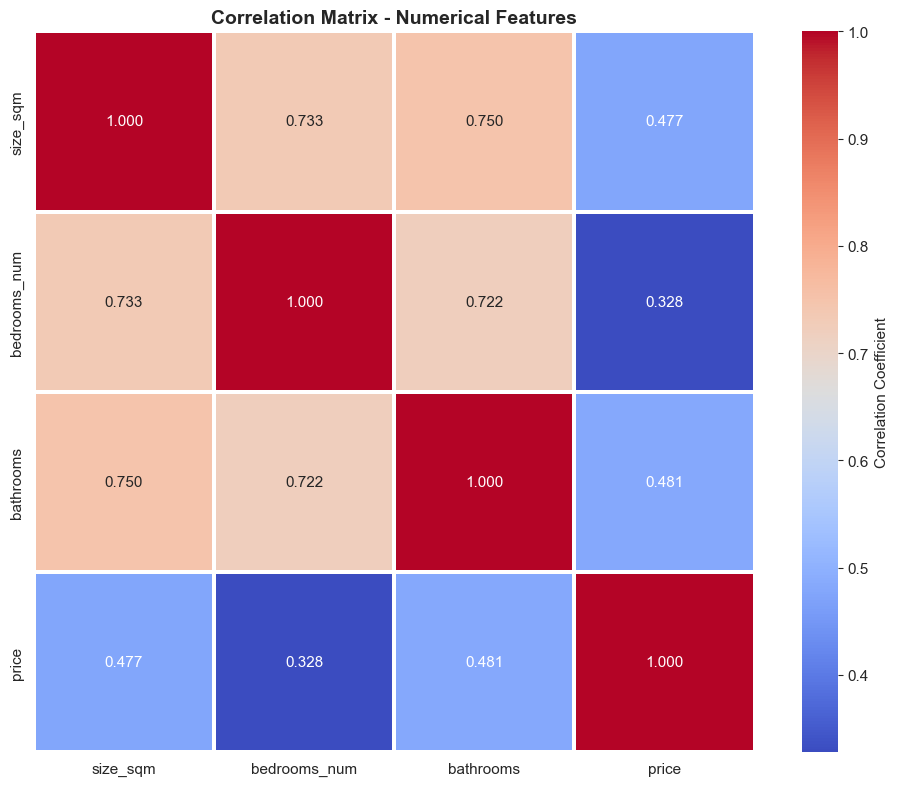

✅ Correlation matrix created

🏘️ Creating top locations plot...


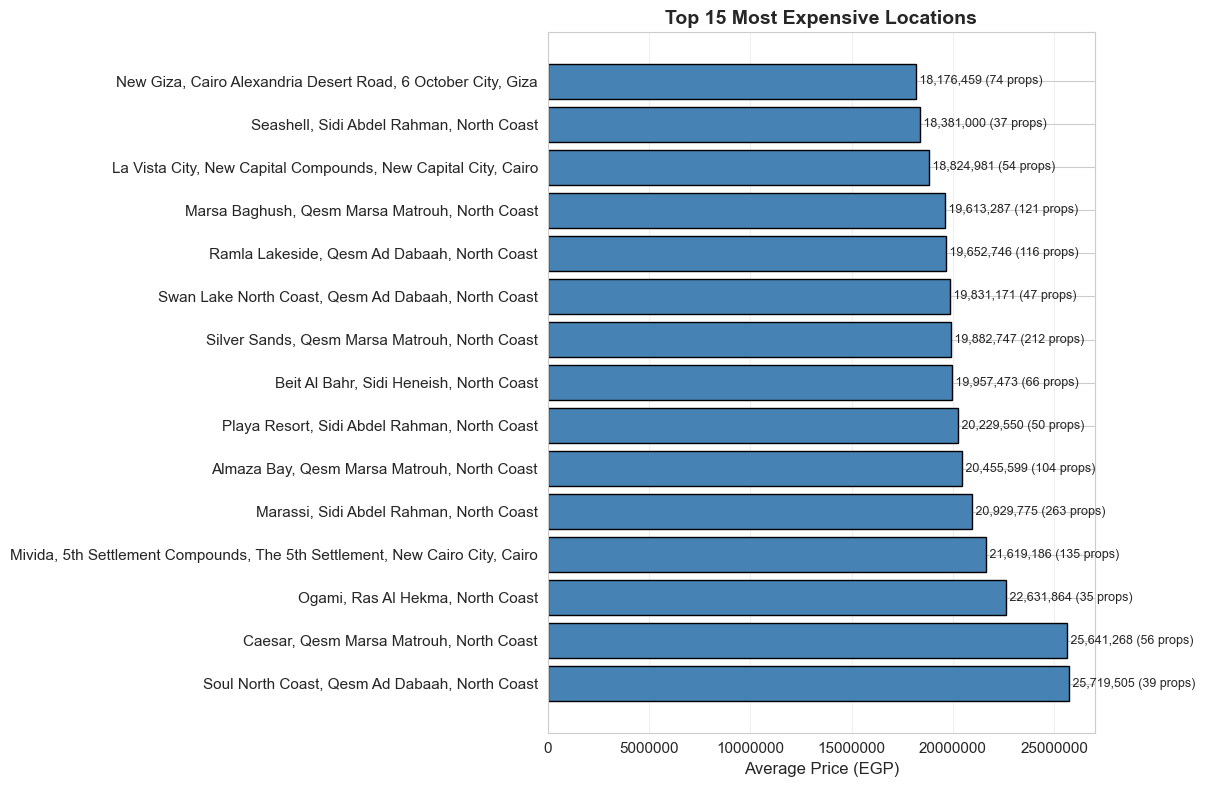

✅ Top 15 locations shown

📍 Creating size vs price scatter plot...


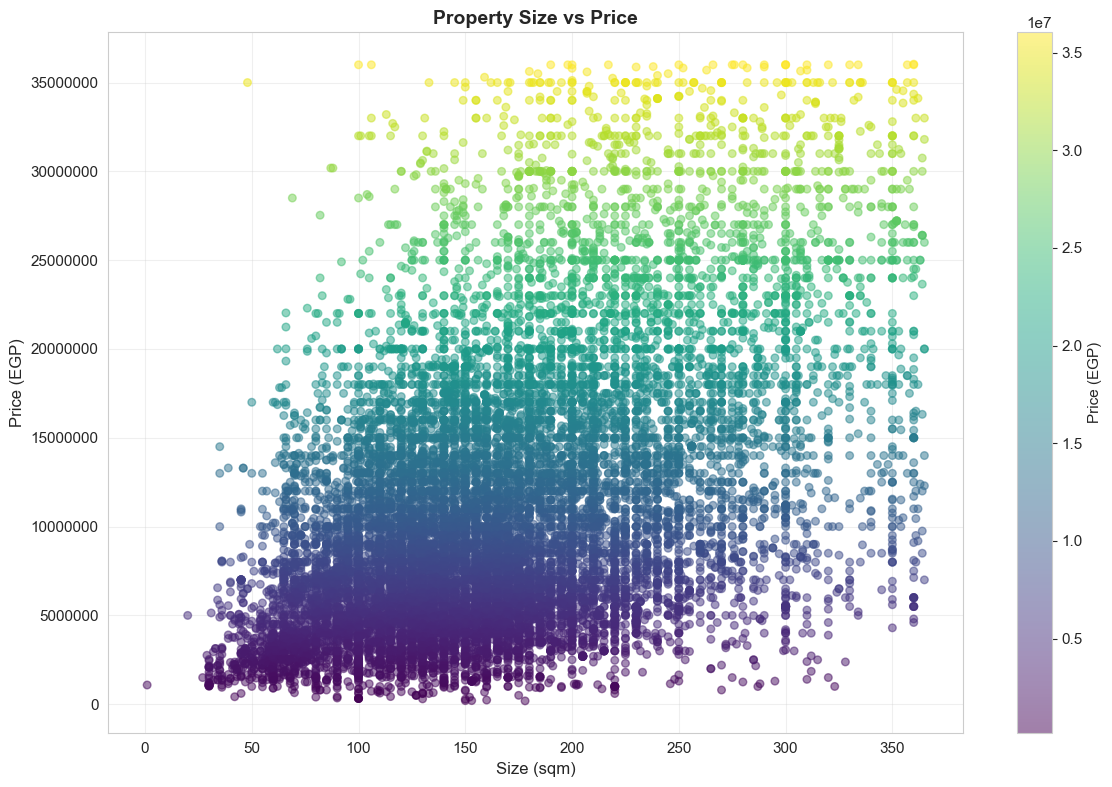

✅ Size vs price scatter created

🏷️ Creating categorical distributions...


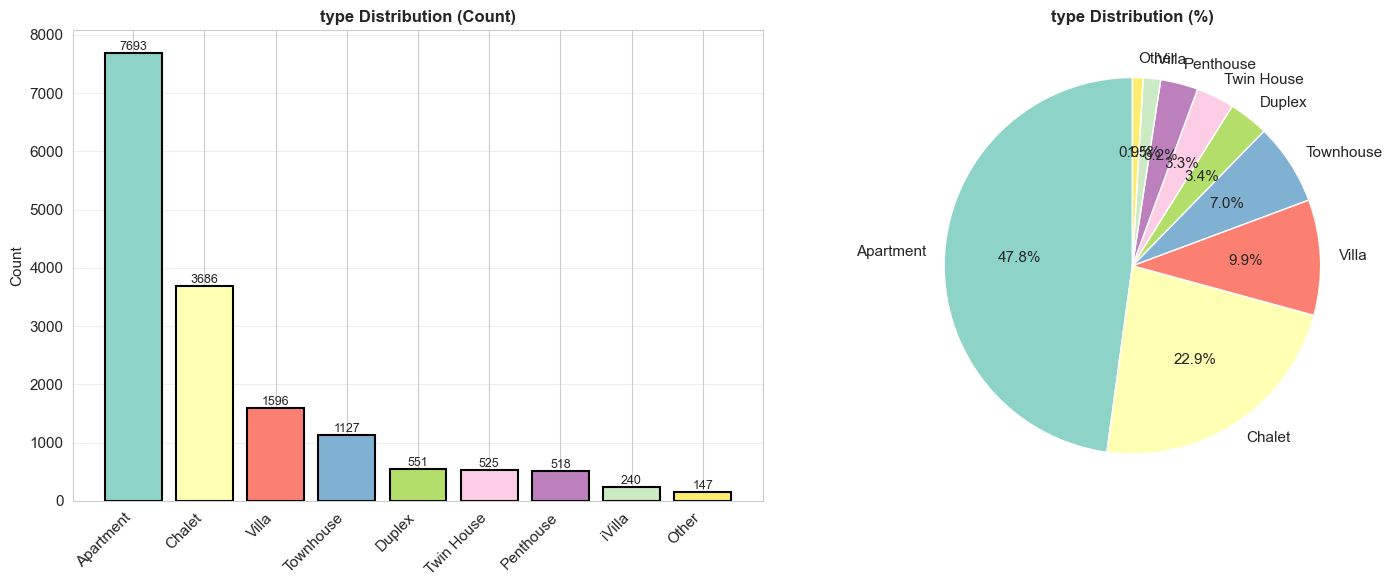

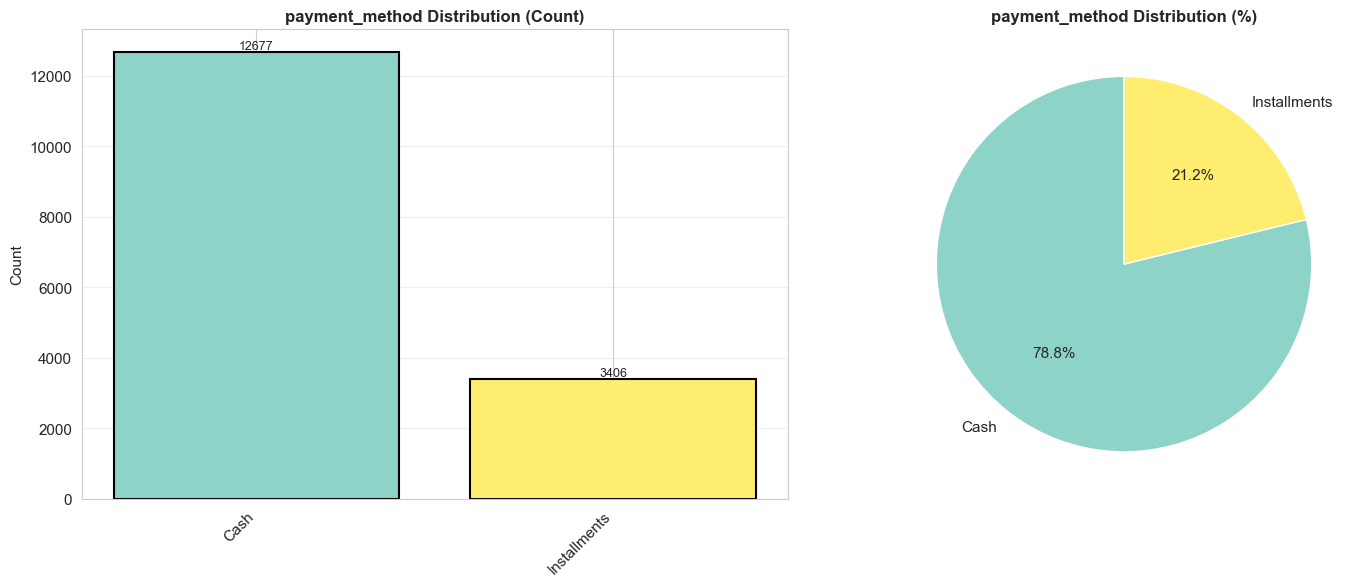

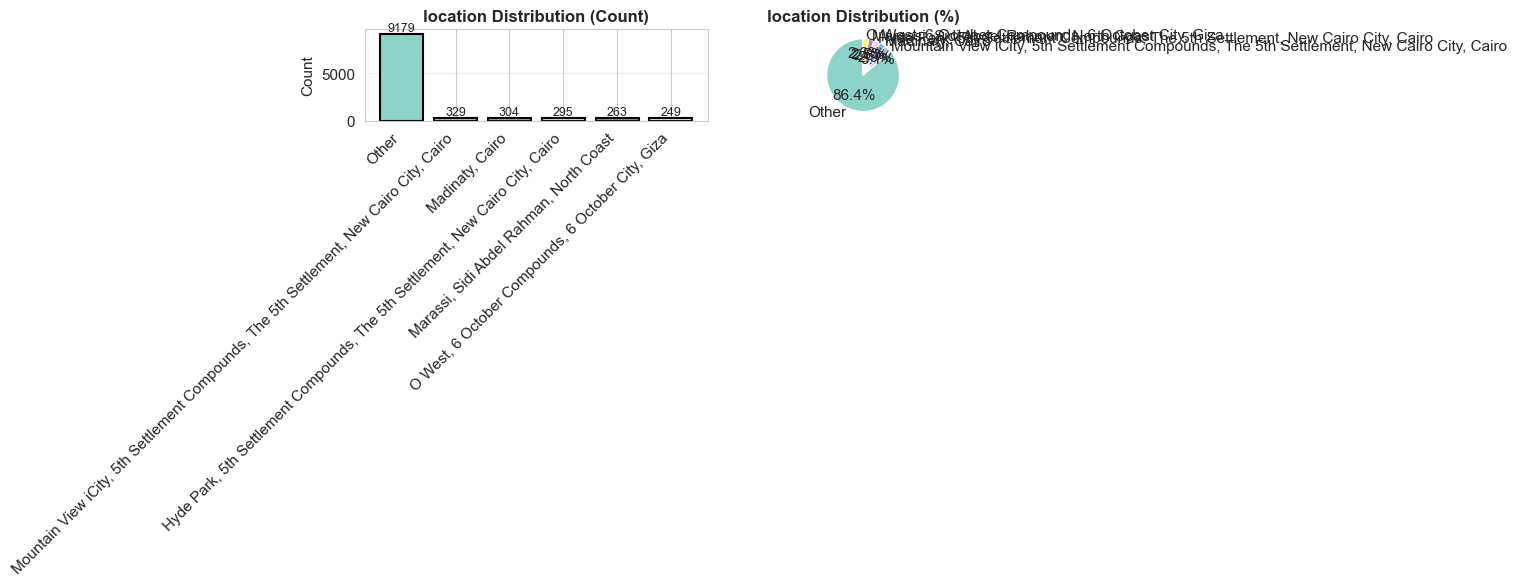

✅ Categorical distributions created

SUMMARY STATISTICS

1. NUMERICAL FEATURES:
       size_sqm  bedrooms_num  bathrooms        price
count  16083.00      16083.00   16083.00     16083.00
mean     168.82          2.79       2.67  11272990.56
std       67.06          0.88       1.03   7426338.66
min        1.00          1.00       1.00    186900.00
25%      120.00          2.00       2.00   5650000.00
50%      160.00          3.00       3.00   9300000.00
75%      210.00          3.00       3.00  15221765.00
max      365.00          7.00       7.00  36035000.00

2. CATEGORICAL FEATURES:

type:
type
Apartment          7693
Chalet             3686
Villa              1596
Townhouse          1127
Duplex              551
Twin House          525
Penthouse           518
iVilla              240
Hotel Apartment      92
Cabin                37
Name: count, dtype: int64

payment_method:
payment_method
Cash            12677
Installments     3406
Name: count, dtype: int64

location:
location
Other   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ====================== Setup ======================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

project_path = r'F:\Egypt-Real-Estate-Appraiser'
os.chdir(project_path)

print("=" * 80)
print("EXPLORATORY DATA ANALYSIS - EGYPT REAL ESTATE")
print("=" * 80)
print(f"Working directory: {os.getcwd()}\n")

# ====================== Load Cleaned Data ======================
print("📊 Loading cleaned data...")
df = pd.read_pickle('data/cleaned_data.pkl')

print(f"✅ Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

# Convert numeric columns to be safe
numeric_cols = ['size_sqm', 'bedrooms_num', 'bathrooms', 'price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values after loading:")
print(df[numeric_cols].isnull().sum())
print()

# ====================== 1. Price Distribution ======================
print("📈 Creating price distribution plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
axes[0].hist(df['price'], bins=50, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (Linear Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (EGP)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(np.log1p(df['price']), bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Price statistics:")
print(f"  Mean: {df['price'].mean():,.0f} EGP")
print(f"  Median: {df['price'].median():,.0f} EGP")
print(f"  Std Dev: {df['price'].std():,.0f} EGP")
print(f"  Range: {df['price'].min():,.0f} - {df['price'].max():,.0f} EGP\n")

# ====================== 2. Price by Property Type ======================
print("📊 Creating boxplot by property type...")

plt.figure(figsize=(14, 7))
property_order = df.groupby('type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='type', y='price', order=property_order, palette='Set2')
plt.title('Price Distribution by Property Type', fontsize=14, fontweight='bold')
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Price (EGP)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('reports/price_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Average Price by Property Type:")
avg_by_type = df.groupby('type')['price'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
print(avg_by_type.round(0))
print()

# ====================== 3. Correlation Heatmap ======================
print("🔥 Creating correlation heatmap...")

# Ensure numeric columns
numeric_cols_plot = ['size_sqm', 'bedrooms_num', 'bathrooms', 'price']
df_numeric = df[numeric_cols_plot].copy()
for col in numeric_cols_plot:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

df_numeric = df_numeric.dropna()

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1.5, 
            cbar_kws={'label': 'Correlation Coefficient'}, square=True)
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation matrix created\n")

# ====================== 4. Top Locations ======================
print("🏘️ Creating top locations plot...")

top_locations = df.groupby('location')['price'].agg(['count', 'mean']).sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_locations)), top_locations['mean'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_locations)), top_locations.index)
plt.xlabel('Average Price (EGP)', fontsize=12)
plt.title('Top 15 Most Expensive Locations', fontsize=14, fontweight='bold')
plt.ticklabel_format(style='plain', axis='x')
for i, (idx, row) in enumerate(top_locations.iterrows()):
    plt.text(row['mean'], i, f" {row['mean']:,.0f} ({int(row['count'])} props)", va='center', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('reports/top_locations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Top 15 locations shown\n")

# ====================== 5. Size vs Price Scatter ======================
print("📍 Creating size vs price scatter plot...")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['size_sqm'], df['price'], alpha=0.5, c=df['price'], cmap='viridis', s=30)
plt.xlabel('Size (sqm)', fontsize=12)
plt.ylabel('Price (EGP)', fontsize=12)
plt.title('Property Size vs Price', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, label='Price (EGP)')
cbar.formatter.set_powerlimits((0, 0))
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/size_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Size vs price scatter created\n")

# ====================== 6. Categorical Features ======================
print("🏷️ Creating categorical distributions...")

def plot_categorical_safe(df, column, top_n=8):
    """Safely plot categorical features"""
    plt.figure(figsize=(15, 6))
    
    counts = df[column].fillna('Missing').value_counts()
    top_counts = counts[:top_n]
    other_sum = counts[top_n:].sum()
    
    plot_data = top_counts.copy()
    if other_sum > 0:
        plot_data['Other'] = other_sum
    
    categories = list(plot_data.index)
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
    
    # Subplot 1: Bar chart
    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(plot_data)), plot_data.values, color=colors, edgecolor='black', linewidth=1.5)
    plt.xticks(range(len(plot_data)), categories, rotation=45, ha='right')
    plt.ylabel('Count', fontsize=11)
    plt.title(f'{column} Distribution (Count)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # Subplot 2: Pie chart
    plt.subplot(1, 2, 2)
    plt.pie(plot_data.values, labels=categories, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'{column} Distribution (%)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'reports/{column}_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot categorical features
plot_categorical_safe(df, 'type', top_n=8)
plot_categorical_safe(df, 'payment_method', top_n=5)
plot_categorical_safe(df, 'location', top_n=6)

print("✅ Categorical distributions created\n")

# ====================== 7. Summary Statistics ======================
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print("\n1. NUMERICAL FEATURES:")
print(df[['size_sqm', 'bedrooms_num', 'bathrooms', 'price']].describe().round(2))

print("\n2. CATEGORICAL FEATURES:")
for col in ['type', 'payment_method', 'location']:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))

print("\n3. PRICE PER SQM ANALYSIS:")
df['price_per_sqm_calc'] = df['price'] / df['size_sqm']
print(f"Mean price/sqm: {df['price_per_sqm_calc'].mean():,.0f} EGP")
print(f"Median price/sqm: {df['price_per_sqm_calc'].median():,.0f} EGP")
print(f"Std Dev price/sqm: {df['price_per_sqm_calc'].std():,.0f} EGP")

print("\n" + "=" * 80)
print("✅ EDA COMPLETED SUCCESSFULLY!")
print("=" * 80)
print("\nAll visualizations saved to 'reports/' folder")
